#task 1
1. Part 2 ile başla. Önceki üç harfi bağlam alan veri setini kur (X: 3
harf indeksi, Y: sıradaki harf). Embedding tablosunu (27x2) oluştur,
indeksleme ile embedding'leri çek. (Part 2, 9:03 - 18:35)

In [102]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [103]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [104]:
#char to int ve int to char mapping
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [105]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility

In [106]:
block_size = 3 # bigram modelin genellestirilmis hali
X,Y= [],[]

for w in words:
  #print(w)
  context = [0]*block_size # her seferinde resetlemek gerekiyor contexti yoksa karisir
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context ),'---->',itos[ix])
    context = context[1:]+[ix]

X = torch.tensor(X)
Y = torch.tensor(Y) # training ve prediction dataseti olusturumu

In [107]:
C = torch.randn((27,10),generator=g) # embedding matrix
emb = C[X]
emb.shape

torch.Size([228146, 3, 10])

#task 2
2. Gizli katmanı ve çıkış katmanını kur: embedding'leri düzleştir, W1
ve b1 ile tanh, W2 ve b2 ile logits. Loss'u geçen haftaki gibi elle
hesapla, sonra F.cross_entropy ile aynı sonucu aldığını göster ve
neden onu tercih ettiğimizi videodan anla. (18:35 - 37:56)

In [108]:
W1 = torch.randn((30,200),generator=g) #makaledeki ornekte 3 input var 2 dimension her biri icin 2*3=6
b1 = torch.randn(200,generator=g) # 100 noron tamamen keyfi bir deger
# fakat dimension mismatch oldugundan dolayi matrix carpimi yapamiyoruz o yuzden emb matrixini concat etmemiz gerkeiyor

In [109]:
# emb @ W1 + b

In [110]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([228146, 30])

In [111]:
torch.cat(torch.unbind(emb, 1), 1).shape # daha generalized versiyonu

torch.Size([228146, 30])

In [112]:
h = torch.tanh(emb.view(-1,30)@W1+b1) # hidden layer

In [113]:
# simdi output layeri yapalim
W2 = torch.randn((200,27),generator=g)
b2 = torch.randn(27,generator=g)
logits = h@W2+b2
counts =logits.exp() #softmax functionu implement edelim
prob = counts/counts.sum(1,keepdims = True)
parameters = [C,W1,b1,W2,b2]

In [114]:
# loss = -prob[torch.arange(32),Y].log().mean() #nll loss

In [115]:
for p in parameters:
    p.requires_grad = True

# task 3
3. Eğitim döngüsünü kur: önce tek bir minibatch'i overfit et, sonra
bütün veriyi minibatch'lerle eğit. Learning rate'i videodaki gibi tara
ve iyi bir değer seç. Veriyi train / dev / test olarak böl, loss'u dev
üzerinde raporla. (37:56 - 1:00:49)

In [116]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [117]:
lri = []
lossi= []
stepi = []

In [120]:

for i in range(50000):
  #minibatch construct
  ix = torch.randint(0,Xtr.shape[0],(32,))
  #tum forward pass packed together
  emb = C[Xtr[ix]] # tum train seti vermek yerine sample veriyoruz daha hizli train olmasi icin
  h = torch.tanh(emb.view(-1,30)@W1+b1)
  logits = h@W2+b2
  loss = F.cross_entropy(logits,Ytr[ix]) # cross entropy function softmax + NLLi tek bir asamada hesapliyor ve daha hizli
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  # update
  #lr = lrs[i]
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad

  #track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())
print(loss.item())


2.500209331512451


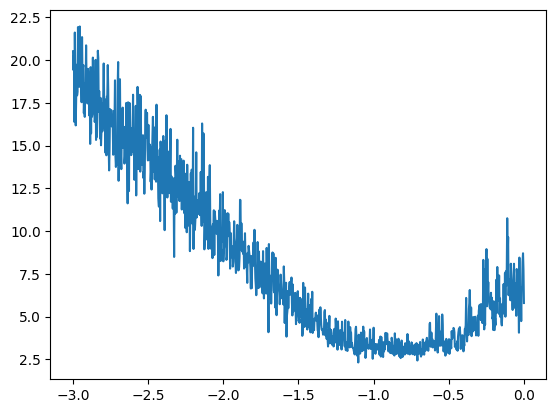

In [58]:
plt.plot(lri,lossi) # bu plot ile LR icin sweetspotu ariyoruz
# bu log plotu oldugu icin 1e-1 bizim icin oldukca iyi bir lR oldugunu anliyoruz yani 0.1

In [59]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
# modelin overfit etmesini onlemek icin

In [118]:
# build the dataset
def build_dataset (words):
  block_size = 3 # context length: how many characters do we take to predict the next one?
  X, Y = [],[]
  for w in words:
  #print (W)
    context = [0] * block_size
    for ch in w +'.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
    #print(''.join(itos[i] for i in context), '-—›', itos[ix])
      context = context[1:] + [ix] # crop and append
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y


import random
random.seed (42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words [n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


#task 4
4. Gizli katmanı ve embedding boyutunu büyütüp dev loss'un nasıl
değiştiğini göster. Embedding'leri 2 boyutta çizdir: hangi harfler
birbirine yakın düşüyor? Modelden isimler örnekle, bigram'ınkilerle
karşılaştır. (1:00:49 - 1:13:24)

In [90]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss # tr loss


tensor(2.4349, grad_fn=<NllLossBackward0>)

In [91]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss
# dev loss

tensor(2.4716, grad_fn=<NllLossBackward0>)

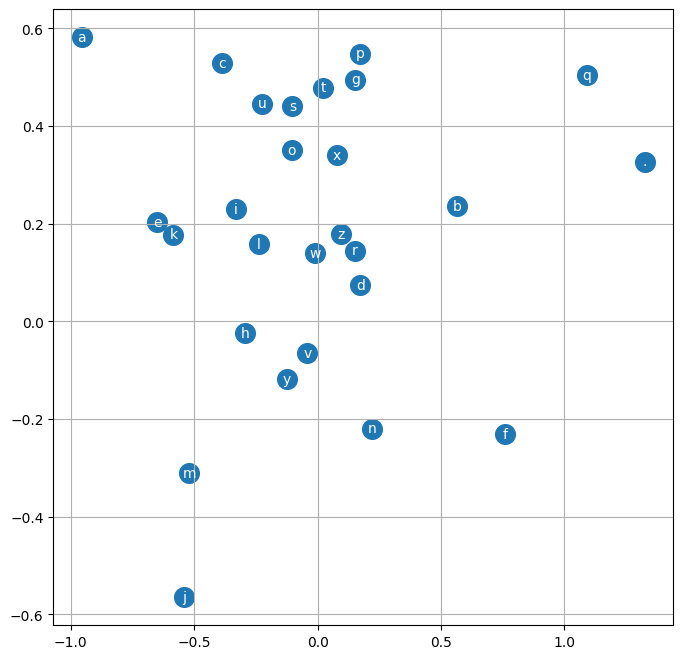

In [123]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200) # embedding dimension 2 oldugu icin plot edebiliyoruz ama 2 yetersiz kaliyor duzgun ogrenme icin
for i in range(C.shape [0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [122]:
#sampling
# sample from the model
g = torch.Generator() .manual_seed(2147483647)
for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1, block_size, d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append (ix)
      if ix == 0:
        break
    print(''.join(itos[i] for i in out))

dex.
maleah.
makila.
kayha.
kalimitta.
malande.
katha.
samiyah.
jakhi.
gotti.
mozie.
kado.
key.
edo.
kadiya.
madde.
enkavirny.
foltp.
huliven.
tah.


In [ ]:
#-------------------------------------------------------------------------------

In [124]:
# task 5e gecmeden once geleneksel LOL datasetimiz ile train edip samplelayalim
words = open('lol_nickler.txt','r').read().splitlines()
words[:8]


['aaron',
 'abaddon',
 'abagnale',
 'abbedagge',
 'abedz',
 'ablazeolive',
 'able',
 'abloopu']

In [125]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([20360, 3]) torch.Size([20360])
torch.Size([2538, 3]) torch.Size([2538])
torch.Size([2604, 3]) torch.Size([2604])


In [126]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [127]:
for p in parameters:
  p.requires_grad = True

lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

lri = []
lossi = []
stepi = []


In [128]:
for i in range(200000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())


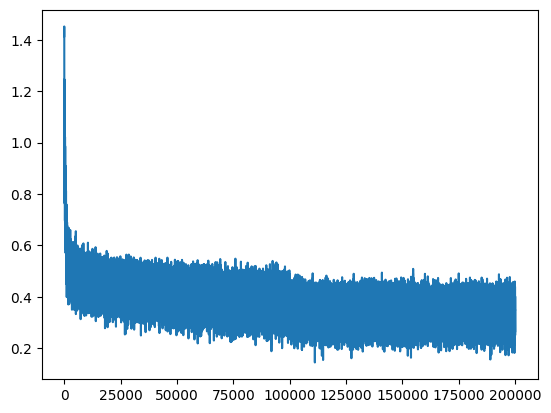

In [129]:
plt.plot(stepi,lossi)

In [133]:
#sampling
# sample from the model
g = torch.Generator() .manual_seed(2147483648+ 10)
for _ in range(50):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1, block_size, d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append (ix)
      if ix == 0:
        break
    print(''.join(itos[i] for i in out))

nacere.
dephoen.
martch.
yapoxkvoy.
baxanx.
tumri.
dhmxite.
docel.
vanat.
jkjk.
blas.
guipaina.
omantlest.
royahanj.
elran.
mima.
phoneshorysua.
het.
seachan.
nis.
tutch.
chri.
mave.
yinnazarory.
xinyuahir.
ruina.
ofergs.
betrux.
esrock.
cherggevo.
luka.
yachondebergs.
akumos.
all.
rottlarl.
thismasuzi.
nic.
shanicore.
tan.
guer.
yrem.
pemasteon.
iymeitua.
beunox.
iki.
bar.
treshoon.
dabe.
roto.
ljoelissloni.


#task 5
model hic egitilmemisken her araktere esit olasilik verirse log(1/27) olur bu da bizim teorik referansimiz.

ama w2 ve b2 rastgele baslatildigi zaman logit degerleri buyuk degerler aldigi icin bu degerler softmaxde abartilip bazi sacma degerlere neredeyse 1 olasilik veriyor.

yani model 'confidently wrong' davraniyor.ilk yuz veya bin iterasyon bunun yuzunden bosa harcaniyor. compute israfi.
cozum olarak w2 ve b2yi kucuk bir sabitle carparak logitlerin patlamasini engelleyebiliriz

----
tanh neden doyuyor:
h = tanh(embcat @ W1 + b1). w1 olceksiz baslatilinca tanha giren degerler buyuk mutlak degerli oluyor ayni softmaxdeki gibi tanhda +-1 e sature oluyor. sebebi ise microgradda yaptigimiz tanhin turevinde yatiyor.

tanh'(x) = 1 - tanh(x)².

tanh +-1 oldugunda bu turev sifira yakin olur ve out.gradi da sifirliyor. agirliklar guncellenmedigi icin o noron bir sey ogrenemez.

cozum olarak keyfi bir 'sweet spot' kucuk sayi ile olcekleyebiliriz yukaridaki gibi fakat kaiming init ile direkt formul uzerinden olcek katsayisini da hesaplayabiliriz


#task 6

Neden gerekli, Kaiming yetmiyor mu? Kaiming init sadece başlangıçta preactivation dağılımını düzeltiyor. Eğitim ilerledikçe W1 güncellene güncellene bu iyi dağılım yine bozulabilir (özellikle derin ağlarda). BatchNorm bunu her adımda zorla düzeltiyor:

her minibatch'te preactivation'ın o batch içindeki ortalama ve varyansını hesaplayıp (x - mean) / sqrt(var + eps) ile normalize ediyor, sonra öğrenilebilir bngain ve bnbias ile tekrar ölçekleyip kaydırıyor (ağın normalizasyonu gerekirse "geri alabilmesi" için).

Eğitim vs tahmin farkı — running mean: Eğitimde batch istatistiği anlamlı ama tahminde (özellikle tek bir örnek üzerinde) batch istatistiği hesaplamak anlamsız/kararsız. Bu yüzden eğitim sırasında bnmean_running ve bnvar_running diye bir de üstel hareketli ortalama (EMA) tutuyorsun — her adımda gerçek batch istatistiğinin küçük bir payını (örn. momentum 0.001) bunlara ekliyorsun, torch.no_grad() içinde, çünkü bunlar parametre değil sadece takip edilen buffer. Tahmin zamanı batch istatistiği yerine bu sabit running değerleri kullanıyorsun.

Küçük ama pratik bir detay: BatchNorm zaten preactivation'ın ortalamasını çıkardığı için b1'in hiçbir etkisi kalmıyor — genelde kaldırılır, kayma işini bnbias üstlenir.

Karşılaştırmada beklenti: Bu küçük modelde BatchNorm'lu/BatchNorm'suz dev loss farkının büyük çıkmasını bekleme, videoda da marjinal. Asıl kazanç derin ağlarda ortaya çıkıyor — BatchNorm, başlangıç ölçeklendirmesine bağımlılığı azaltıp aktivasyon dağılımını eğitim boyunca stabilize ediyor. (Yan not: bir örneğin çıktısı, aynı batch'teki diğer örneklere bağımlı hale geliyor — bu hem hafif bir regularizasyon etkisi hem de garip bir yan etki; LayerNorm gibi alternatiflerin doğma sebeplerinden biri de bu.)